
#***Práctica 2 Modelo cinemático inverso de un manipulador y planteamiento de trayectoria***



**Objetivo**

El objetivo de esta práctica es que el alumno comprenda, interprete y modifique el modelo de cinemática directa e inversa d eun moanipulador serial.
Metas

*   Que el alumno aplique un modelo cinemático, obteniendo las matrices de transformación y la postura del manipulador
*   Que el alumno aplique un modelo cinemático inverso para calcular una trayectoria a partir de una posición actual hacia una posición final
*   Que el alumno grafique y analice los resultados del modelo



**Robotica** <br>
<Profesor:> <br>
Roberto García García <br>

<Integrantes:> <br>
*Gutiérrez Iglesias Jezreel Amir* <br>
*Oropeza Medina Hiram David* <br>
*Torres Fragoso José Eduardo*<br> <br>
Grupo 1 <br>
Semestre 2026-2

##**Cuestionario previo**

###1. ¿Que son las transformaciones homogéneas?

Las transformaciones homogéneas son fundamentales en la robótica para representar y manipular la posición y orientación de cuerpos rígidos en el espacio tridimensional. Al combinar la rotación y la traslación en una sola matriz de 4×4, estas transformaciones permiten la concatenación fluida de múltiples conversiones de marcos de coordenadas.

###2. ¿Que nos permite obtener el modelo de cinemática directa de un manipulador?

El modelo de cinemática directa permite calcular la posición y orientación del efector final (la "mano" o herramienta del robot) en el espacio cartesiano, basándose únicamente en los valores actuales de las variables articulares (ángulos de las juntas o desplazamientos prismáticos).En términos matemáticos, si $q$ es el vector de posiciones articulares, la cinemática directa es una función:$$X = f(q)$$Donde $X$ representa la pose (posición y orientación) del efector final. Es la relación que responde a la pregunta: "Si muevo mis articulaciones a estos ángulos específicos, ¿dónde quedará mi herramienta?".

###3. ¿Que nos permite obtener el modelo de cinemática inversa de un manipulador?



El modelo de cinemática inversa permite obtener los valores necesarios de las variables articulares ($q$) para que el efector final alcance una posición y orientación deseadas ($X$) en el espacio de trabajo.Es decir, resuelve la función inversa:$$q = f^{-1}(X)$$Es fundamental para la programación de robots, ya que permite al usuario definir una trayectoria en el espacio (coordenadas $(x, y, z)$ y ángulos de Euler/cuaterniones) y dejar que el controlador del robot calcule cómo deben moverse los motores para seguir esa trayectoria. Es computacionalmente más complejo que la cinemática directa y puede tener múltiples soluciones o ninguna solución (si el punto está fuera del alcance del robot).

###4. ¿De que formas se puede interpolar la trayectoria de un efector final entre dos puntos?

1. Interpolación en el Espacio de Articulaciones (Joint Space)

Los cálculos se hacen directamente sobre los ángulos/posiciones de cada articulación. El robot genera la trayectoria en el espacio cartesiano de forma implícita.

2. Interpolación en el Espacio Cartesiano (Task Space)

La trayectoria se define directamente en el espacio 3D. Requiere cinemática inversa en cada paso de tiempo.

3. Métodos Avanzados

Bezier y B-Splines — Control geométrico intuitivo de la forma de la curva mediante puntos de control.
NURBS — Generalizan las B-Splines con pesos, permiten representar cónicas exactas.
Interpolación basada en tiempo mínimo / energía mínima — Optimización con restricciones de torque, velocidad y aceleración.
Planificación probabilística (RRT, PRM) — Para entornos con obstáculos, no deterministas.

##**Desarrollo**
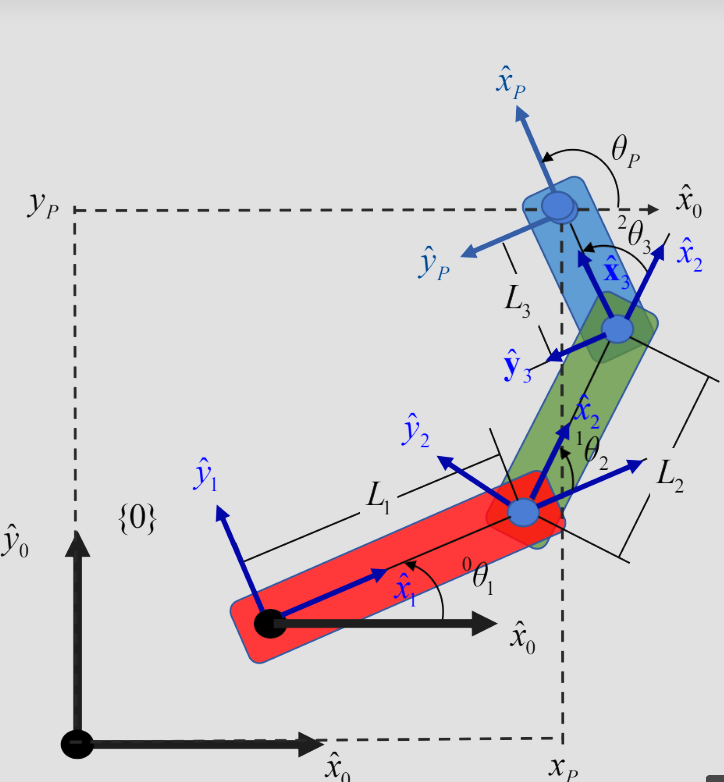

###1. Planteamiento de la cinemática directa
En esta sección se plantea la cinemática directa de un robot tipo RRR de tres grados de libertad que se mueve en el plano XY. Como las tres articulaciones son rotacionales y giran alrededor del eje Z, se define una matriz de rotación en Z para representar el movimiento angular de cada junta.

Posteriormente, se construyen las transformaciones homogéneas entre cada sistema de referencia del robot, combinando rotación y traslación. Al multiplicar estas matrices se obtiene la posición y orientación final del efector. Finalmente, se calcula el Jacobiano, el cual permite relacionar los cambios en los ángulos articulares con el movimiento del efector final.



In [12]:

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Definición de variables simbólicas
th1, th2, th3 = sp.symbols('th1 th2 th3')
l1, l2, l3 = sp.symbols('l1 l2 l3')

# Función auxiliar para generar la matriz planar (Rotación Z y traslación X)
def matriz_transformacion(th, l):
    return sp.Matrix([
        [sp.cos(th), -sp.sin(th), 0, l*sp.cos(th)],
        [sp.sin(th),  sp.cos(th), 0, l*sp.sin(th)],
        [0,           0,          1, 0],
        [0,           0,          0, 1]
    ])

# Matrices de transformación homogénea para cada eslabón
T_0_1 = matriz_transformacion(th1, l1)
T_1_2 = matriz_transformacion(th2, l2)
T_2_3 = matriz_transformacion(th3, l3)

# Transformación total desde la base hasta el efector final
T_0_p = T_0_1 * T_1_2 * T_2_3

# Extracción de las expresiones de posición y orientación cartesiana (Plano XY)
x_expr = T_0_p[0, 3]
y_expr = T_0_p[1, 3]
alpha_expr = th1 + th2 + th3  # Suma directa de ángulos para la orientación planar

# Vector de variables de tarea y cálculo del Jacobiano simbólico
X_expr = sp.Matrix([x_expr, y_expr, alpha_expr])
q_expr = sp.Matrix([th1, th2, th3])
J_simb = X_expr.jacobian(q_expr)

# Simplificación trigonométrica del Jacobiano
J_simb = sp.simplify(J_simb)

print("Matriz del Jacobiano simplificada:")
display(J_simb) # Usamos display para que se vea con formato matemático en la libreta


Matriz del Jacobiano simplificada:


Matrix([
[-l1*sin(th1) - l2*sin(th1 + th2) - l3*sin(th1 + th2 + th3), -l2*sin(th1 + th2) - l3*sin(th1 + th2 + th3), -l3*sin(th1 + th2 + th3)],
[ l1*cos(th1) + l2*cos(th1 + th2) + l3*cos(th1 + th2 + th3),  l2*cos(th1 + th2) + l3*cos(th1 + th2 + th3),  l3*cos(th1 + th2 + th3)],
[                                                         1,                                            1,                        1]])

###2. Planteamiento de la trayectoria
Sí, esta parte quedaría así, más breve y lista para tu notebook:

En esta sección se plantea una trayectoria suave para el efector final del robot, usando un polinomio de quinto grado. Este tipo de trayectoria permite que la posición cambie de manera progresiva desde un punto inicial hasta un punto final, manteniendo velocidad y aceleración iguales a cero al inicio y al final del movimiento.

Primero se calcula la posición inicial del efector a partir de los ángulos iniciales de las juntas. Después se define una posición final deseada y se obtiene una función de trayectoria normalizada. Con esta función se generan los valores intermedios de posición, velocidad y aceleración para el efector final, usando una frecuencia de muestreo de 30 muestras por segundo.


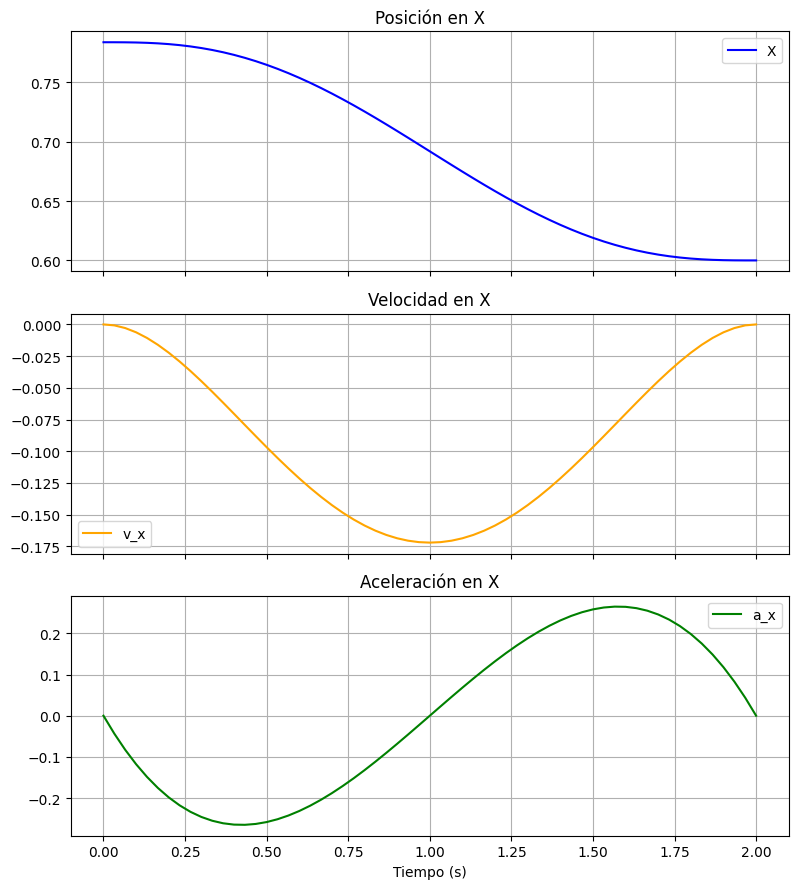

In [13]:

# Definición de las dimensiones fijas de los eslabones
valores_eslabones = {l1: 0.3, l2: 0.3, l3: 0.2}

# Configuración de condiciones iniciales y finales solicitadas
th_init = [0.1, 0.1, 0.1]
P_final = np.array([0.6, 0.3, 0.0])  # xf = [0.6, 0.3, 0]

# Cálculo numérico de la posición inicial del efector a partir de th_init
x_init = float(x_expr.subs(valores_eslabones).subs({th1: th_init[0], th2: th_init[1], th3: th_init[2]}))
y_init = float(y_expr.subs(valores_eslabones).subs({th1: th_init[0], th2: th_init[1], th3: th_init[2]}))
alpha_init = float(alpha_expr.subs({th1: th_init[0], th2: th_init[1], th3: th_init[2]}))
P_init = np.array([x_init, y_init, alpha_init])

# Parámetros de tiempo y muestreo (30 muestras por segundo)
tf = 2.0
frec = 30
n_muestras = int(tf * frec) + 1
t_vec = np.linspace(0, tf, n_muestras)
dt = t_vec[1] - t_vec[0]

# Polinomio de interpolación de 5to grado (Velocidades y aceleraciones nulas en extremos)
tau = t_vec / tf
s = 10 * tau**3 - 15 * tau**4 + 6 * tau**5
s_dot = (30 * tau**2 - 60 * tau**3 + 30 * tau**4) / tf
s_ddot = (60 * tau - 180 * tau**2 + 120 * tau**3) / (tf**2)

# Perfiles de trayectoria en el espacio cartesiano (Solo calculamos X para graficar aquí)
X_t = P_init[0] + (P_final[0] - P_init[0]) * s
X_dot = (P_final[0] - P_init[0]) * s_dot
X_ddot = (P_final[0] - P_init[0]) * s_ddot

# Gráficas del Espacio Cartesiano (Únicamente X)
fig1, axs1 = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

axs1[0].plot(t_vec, X_t, label='X', color='blue')
axs1[0].set_title('Posición en X'), axs1[0].legend(), axs1[0].grid(True)

axs1[1].plot(t_vec, X_dot, label='v_x', color='orange')
axs1[1].set_title('Velocidad en X'), axs1[1].legend(), axs1[1].grid(True)

axs1[2].plot(t_vec, X_ddot, label='a_x', color='green')
axs1[2].set_title('Aceleración en X'), axs1[2].set_xlabel('Tiempo (s)'), axs1[2].legend(), axs1[2].grid(True)

plt.tight_layout()
plt.show()

### 3. Cinemática inversa
En esta sección se plantea la cinemática inversa diferencial del robot. A partir del Jacobiano obtenido previamente, se calcula su matriz inversa para relacionar la velocidad del efector final con las velocidades de las juntas. Es decir, se busca obtener qué tan rápido debe moverse cada articulación para que el efector siga la trayectoria deseada.

Después, usando las velocidades del efector calculadas en la trayectoria, se obtienen las velocidades articulares en cada instante de tiempo. Con esas velocidades se aproximan las posiciones de las juntas mediante integración numérica y las aceleraciones mediante diferencias entre velocidades consecutivas.


In [14]:

# Calculamos Y y Alpha para usarlos en el paso 4, aunque no los grafiquemos
Y_dot = (P_final[1] - P_init[1]) * s_dot
Alpha_dot = (P_final[2] - P_init[2]) * s_dot

# Conversión del Jacobiano simbólico a una función numérica rápida de NumPy
J_num = sp.lambdify((th1, th2, th3, l1, l2, l3), J_simb, 'numpy')

# Inicialización de arreglos globales para registrar el comportamiento de las articulaciones
th_res = np.zeros((3, n_muestras))
th_dot_res = np.zeros((3, n_muestras))
th_ddot_res = np.zeros((3, n_muestras))

# Asignación del estado articular inicial
th_res[:, 0] = th_init

print("Variables y funciones numéricas preparadas para la inversión diferencial.")

Variables y funciones numéricas preparadas para la inversión diferencial.


###4. Aplicación de la cinemática inversa
En esta sección final se muestran los resultados de la aplicación de la cinemática inversa sobre la trayectoria previamente calculada. A partir de los puntos de posición, velocidad y aceleración del efector final, se obtuvieron las correspondientes posiciones, velocidades y aceleraciones articulares, almacenadas en los arreglos th_m, th_dot_m y th_dot_dot_m.

Posteriormente, se generan las gráficas de cada una de estas variables en función del tiempo para las tres juntas del robot. Esto permite visualizar cómo evoluciona el movimiento articular durante toda la trayectoria y verificar el comportamiento dinámico de cada actuador.



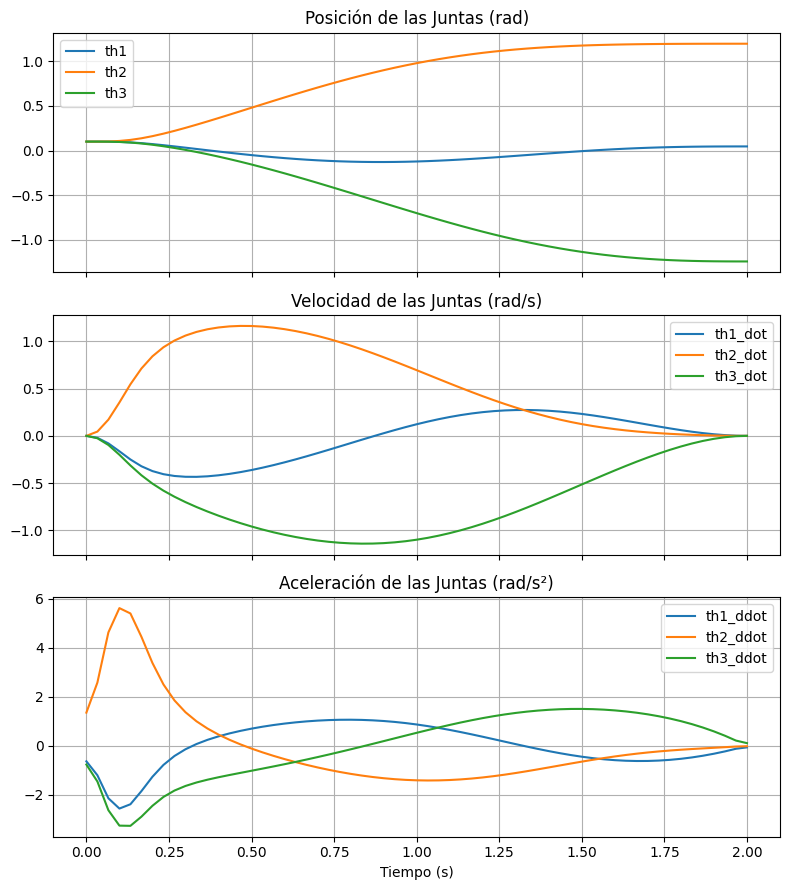

In [15]:
# Bucle de integración numérica temporal
for i in range(n_muestras):
    q_actual = th_res[:, i]

    # Evaluación de la matriz jacobiana con la configuración de juntas del instante actual
    J_eval = J_num(q_actual[0], q_actual[1], q_actual[2],
                   valores_eslabones[l1], valores_eslabones[l2], valores_eslabones[l3])

    # Vector de velocidades cartesianas de entrada
    V_cartesiana = np.array([X_dot[i], Y_dot[i], Alpha_dot[i]])

    # Cálculo de velocidades articulares invirtiendo el Jacobiano
    try:
        q_dot = np.linalg.inv(J_eval) @ V_cartesiana
    except np.linalg.LinAlgError:
        q_dot = np.linalg.pinv(J_eval) @ V_cartesiana  # Pseudoinversa en caso de singularidades

    th_dot_res[:, i] = q_dot

    # Integración numérica de Euler para predecir la siguiente posición articular
    if i < n_muestras - 1:
        th_res[:, i+1] = q_actual + q_dot * dt

# Estimación de las aceleraciones de las juntas utilizando aproximación por diferencias finitas
for i in range(n_muestras):
    if i == 0:
        th_ddot_res[:, i] = (th_dot_res[:, i+1] - th_dot_res[:, i]) / dt
    elif i == n_muestras - 1:
        th_ddot_res[:, i] = (th_dot_res[:, i] - th_dot_res[:, i-1]) / dt
    else:
        th_ddot_res[:, i] = (th_dot_res[:, i+1] - th_dot_res[:, i-1]) / (2 * dt)

# Generación de gráficos del Espacio Articular (Todas las thetas)
fig2, axs2 = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

axs2[0].plot(t_vec, th_res[0, :], label='th1')
axs2[0].plot(t_vec, th_res[1, :], label='th2')
axs2[0].plot(t_vec, th_res[2, :], label='th3')
axs2[0].set_title('Posición de las Juntas (rad)'), axs2[0].legend(), axs2[0].grid(True)

axs2[1].plot(t_vec, th_dot_res[0, :], label='th1_dot')
axs2[1].plot(t_vec, th_dot_res[1, :], label='th2_dot')
axs2[1].plot(t_vec, th_dot_res[2, :], label='th3_dot')
axs2[1].set_title('Velocidad de las Juntas (rad/s)'), axs2[1].legend(), axs2[1].grid(True)

axs2[2].plot(t_vec, th_ddot_res[0, :], label='th1_ddot')
axs2[2].plot(t_vec, th_ddot_res[1, :], label='th2_ddot')
axs2[2].plot(t_vec, th_ddot_res[2, :], label='th3_ddot')
axs2[2].set_title('Aceleración de las Juntas (rad/s²)'), axs2[2].set_xlabel('Tiempo (s)'), axs2[2].legend(), axs2[2].grid(True)

plt.tight_layout()
plt.show()

##**Análisis de resultados**

###1. ¿Qué utilidad tiene el modelo de cinemática inversa de un robot?




La cinemática inversa sirve para saber cómo se deben mover las articulaciones de un robot para que su extremo llegue a un punto específico. En vez de estar probando diferentes movimientos, este modelo ayuda a calcular de forma más directa los ángulos o velocidades que necesita cada junta. Esto es importante porque permite que el robot siga una trayectoria con mayor precisión y pueda realizar tareas como mover piezas, posicionarse en un lugar determinado o ejecutar movimientos controlados.


##**Conclusiones**


Durante la práctica se realizó la explicación y análisis del código utilizado para modelar el movimiento de un robot RRR de tres grados de libertad. Se revisó cómo el programa construye la cinemática directa mediante matrices de rotación y transformaciones homogéneas, además de cómo obtiene la posición y orientación del efector final. También se explicó la función del Jacobiano dentro del código, entendiendo que este permite relacionar el movimiento del efector con el comportamiento de las articulaciones.

Además, se analizó cómo el código genera una trayectoria suave para el efector final y cómo, a partir de la cinemática inversa, obtiene las posiciones, velocidades y aceleraciones de las juntas. Esta práctica permitió comprender mejor cada parte del programa, no solo como instrucciones de Python, sino como una forma de representar matemáticamente el movimiento del robot y visualizar su comportamiento mediante gráficas.


##**Bibliografía**

I. de los Santos Ruiz, "Homogeneous transformations in Robotics: A comprehensive tutorial with examples," Medium. [En línea]. Disponible en: https://medium.com/@idelossantosruiz/homogeneous-transformations-in-robotics-a-comprehensive-tutorial-with-examples-e36cd3709f41


MathWorks, "¿Qué es la cinemática inversa?," MathWorks Discovery, s.f. [En línea]. Disponible en: https://www.mathworks.com/discovery/inverse-kinematics.html

Wikipedia, "Cinemática directa," Wikipedia, La enciclopedia libre, 21 de mayo de 2026. [En línea]. Disponible en: https://es.wikipedia.org/wiki/Cinem%C3%A1tica_directa